<img src="img/logoitqv1.jpg" width="500">
<br>

# 3_2_4_Descriptores_forma

## 0.1 01PAO26-26 - Descriptores de forma
<br>

<img src="img/python_logo.png" width="300">
<br>

*Jesús Viera* https://github.com/Vierita23/machinelearning


In [1]:
import sys
import subprocess
from pathlib import Path

subprocess.run(
    [sys.executable, "-m", "pip", "install", "opencv-python", "matplotlib", "numpy", "scikit-image", "tabulate", "-q"],
    check=False,
)

subprocess.run([sys.executable, "setup_descriptores_images.py"], check=False)

print("Python:", sys.executable)


Python: C:\Users\Jesus\anaconda3\python.exe


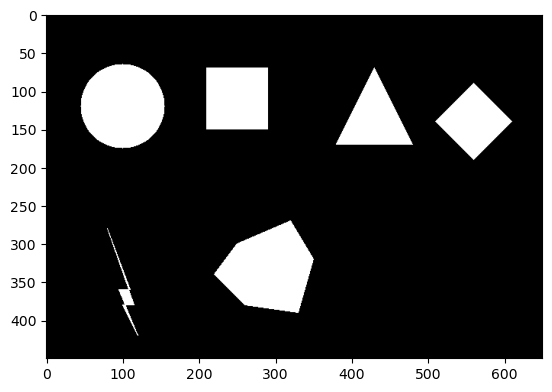

In [2]:
# En primer lugar, obtenemos la máscara de la imagen original mediante la umbralización con Otsu
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = cv2.imread('images/images/figuras.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(img_gray, 0, 1, cv2.THRESH_OTSU)
plt.imshow(mask, cmap='gray')
plt.show()


número de objetos:  6
posibles valores de intensidad:  [0 1 2 3 4 5 6]


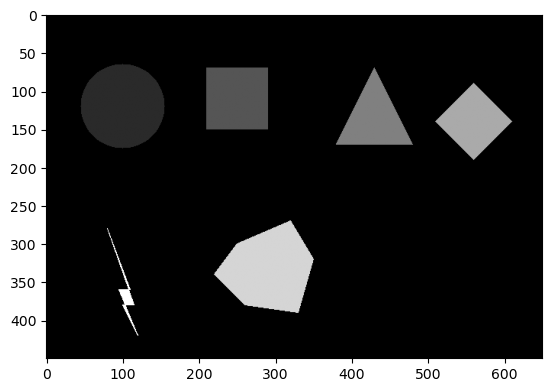

In [3]:
# Convertimos la imagen binaria en una imagen de etiquetas para tener acceso a cada objeto por separado
from skimage.measure import label

lab, num = label(mask, return_num=True)
print('número de objetos: ', num)
v, c = np.unique(lab, return_counts=True)
print('posibles valores de intensidad: ', v)
plt.imshow(lab, cmap='gray')
plt.show()


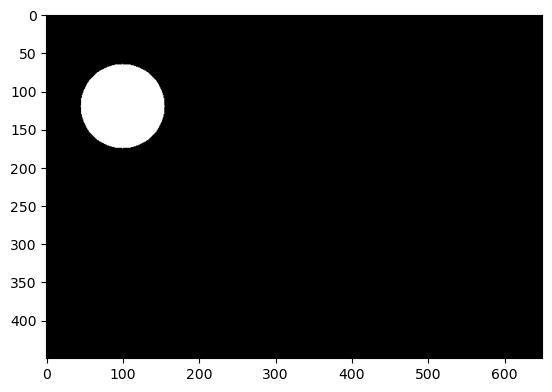

In [4]:
# Podemos acceder de manera independiente al objeto que nos interese a partir de su etiqueta correspondiente
objeto = lab == 1
objeto = objeto.astype('uint8')
plt.imshow(objeto, cmap='gray')
plt.show()


(65, 45, 176, 156)


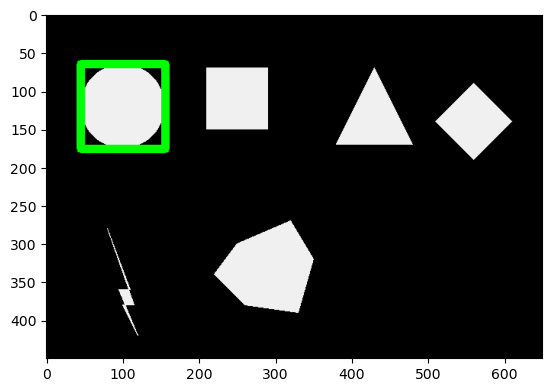

In [5]:
from skimage.measure import regionprops

# Después, podemos extraer la bounding box de dicho objeto
prop = regionprops(objeto)
bbox = prop[0].bbox
print(bbox)
start_point = (bbox[1], bbox[0])
end_point = (bbox[3], bbox[2])
window = cv2.rectangle(img.copy(), start_point, end_point, (0, 255, 0), 10)
plt.imshow(window, cmap='gray')
plt.show()


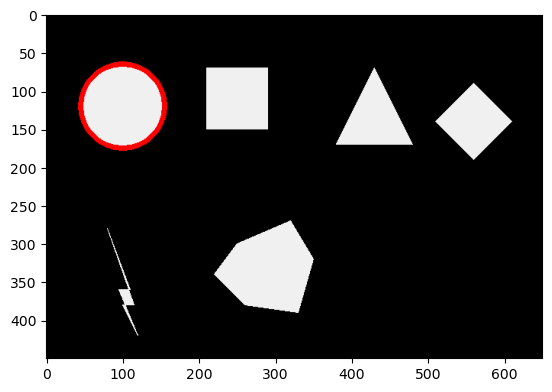

In [6]:
# Y la convex hull image
from skimage.morphology import convex_hull_image

convex_image = convex_hull_image(objeto)
convex_image = convex_image.astype('uint8')
conts, _ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
imagen = cv2.drawContours(img.copy(), conts, -1, (255, 0, 0), 5)
plt.imshow(imagen, cmap='gray')
plt.show()


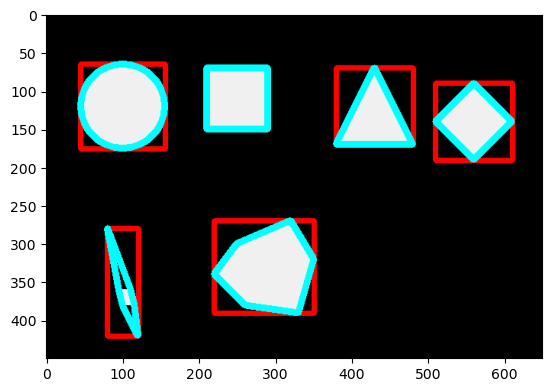

In [7]:
# Repetimos el proceso completo para todos los objetos de la imagen
imagen = img.copy()
for i in range(1, num + 1):
    objeto = lab == i
    objeto = objeto.astype('uint8')
    prop = regionprops(objeto)
    bbox = prop[0].bbox
    imagen = cv2.rectangle(imagen, (bbox[1], bbox[0]), (bbox[3], bbox[2]), (255, 0, 0), 5)
    convex_image = convex_hull_image(objeto)
    convex_image = convex_image.astype('uint8')
    conts, _ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    imagen = cv2.drawContours(imagen, conts, -1, (0, 255, 255), 8)
plt.imshow(imagen, cmap='gray')
plt.show()


In [8]:
# Vamos a extraer diferentes descriptores geométricos que nos ayudarán a caracterizar los objetos.
from tabulate import tabulate
import math

new_lab, new_num = label(mask, return_num=True)
headers = ['', 'Raro', 'Rayo', 'Círculo', 'Cuadrado', 'Triángulo', 'Rombo']
A, BB, CA, E, ED, EX, MA, MiA, OR, P, S, CO, R = ['area'], ['bbox_area'], ['convex_area'], ['eccentricity'], ['equivalent_diameter'], \
    ['extent'], ['major_axis'], ['minor_axis'], ['orientation'], ['perimeter'], ['solidity'], ['compactness'], ['rectangularity']
for i in range(1, new_num + 1):
    objeto = new_lab == i
    prop = regionprops(objeto.astype(np.uint8))
    A.append(np.round(prop[0].area, 4))
    BB.append(np.round(prop[0].bbox_area, 4))
    CA.append(np.round(prop[0].convex_area, 4))
    E.append(np.round(prop[0].eccentricity, 4))
    ED.append(np.round(prop[0].equivalent_diameter, 4))
    EX.append(np.round(prop[0].extent, 4))
    MA.append(np.round(prop[0].major_axis_length, 4))
    MiA.append(np.round(prop[0].minor_axis_length, 4))
    OR.append(np.round(prop[0].orientation, 4))
    P.append(np.round(prop[0].perimeter, 4))
    S.append(np.round(prop[0].solidity, 4))
    CO.append(np.round(4 * math.pi * prop[0].area / prop[0].perimeter ** 2, 4))
    R.append(np.round(prop[0].area / prop[0].bbox_area, 4))
my_data = [tuple(A), tuple(BB), tuple(CA), tuple(E), tuple(ED), tuple(EX),
           tuple(MA), tuple(MiA), tuple(OR), tuple(P), tuple(S), tuple(CO), tuple(R)]
print(tabulate(my_data, headers=headers))


                           Raro       Rayo     Círculo    Cuadrado    Triángulo      Rombo
-------------------  ----------  ---------  ----------  ----------  -----------  ---------
area                  9477       6561        5151        5101        10226        556
bbox_area            12321       6561       10201       10201        15851       5781
convex_area           9597       6561        5250        5101        10354       1444
eccentricity             0          0           0.4999      0            0.4386     0.9922
equivalent_diameter    109.848     91.3987     80.9843     80.5903     114.106     26.6068
extent                   0.7692     1           0.505       0.5          0.6451     0.0962
major_axis             109.848     93.5236     95.6847     82.4702     122.322    117.074
minor_axis             109.848     93.5236     82.8714     82.4702     109.93      14.625
orientation             -0.7854    -0.7854      0.0006     -0.7854      -1.2248     0.2236
perimeter       